# 07b — Dynamic Semi-Hard Siamese Tumor + Healthy

## Obiettivo

Addestrare da zero una Siamese Network utilizzando un curriculum
di negative mining dinamico.

La pipeline mantiene la formulazione pairwise:

FCGR A → shared CNN V3 → embedding A
                             │
                             ├── Euclidean Distance
                             │
FCGR B → shared CNN V3 → embedding B
                             ↓
                     Contrastive Loss

## Strategia

### Fase 1 — Random warm-up

Per le prime epoche vengono utilizzate coppie positive e negative
casuali, come nella baseline originale.

Questo permette alla CNN di costruire uno spazio latente iniziale.

### Fase 2 — Dynamic semi-hard mining

Dopo il warm-up, per ogni anchor vengono campionati:

- un positive della stessa classe;
- più negative candidate appartenenti a classi differenti.

Il modello corrente calcola le distanze nello spazio embedding.

Una negative è considerata semi-hard quando:

d(anchor, positive) < d(anchor, negative) < margin

Tra le candidate valide viene scelta quella più vicina.

Il mining viene quindi ricalcolato dinamicamente durante il training
e non deriva da un checkpoint precedente.

## Configurazione

- Task: 12 Tumor + Healthy
- FCGR: k=6
- Encoder: CNN V3
- Embedding: 128D L2-normalizzato
- Downsampling: 2111 sample/class
- Euclidean Contrastive Loss
- Margin: 1.25
- Warm-up: random pairs
- Mining: dynamic semi-hard
- Test set non utilizzato

In [2]:
# ============================================================
# CELL 2 — IMPORTS + CONFIG
# ============================================================

from pathlib import Path

import random
import time
import copy
import json

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import (
    Dataset,
    DataLoader
)

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)


# ============================================================
# PROJECT
# ============================================================

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)


PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)


ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_semihard_tumor_healthy"
)


ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# PATHS
# ============================================================

MANIFEST_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_manifest.tsv"
)


CLASS_MAPPING_PATH = (
    PROCESSED_DIR
    / "siamese_tumor_healthy_class_mapping.tsv"
)


VAL_POOL_PATH = (
    PROCESSED_DIR
    / "siamese_val_pair_pool.tsv"
)


PAIR_CONFIG_PATH = (
    PROCESSED_DIR
    / "siamese_pair_config.json"
)



# ============================================================
# PAIR CONFIG
# ============================================================

with open(
    PAIR_CONFIG_PATH,
    "r",
    encoding="utf-8"
) as f:

    pair_config = json.load(f)


K = int(
    pair_config["k"]
)

RANDOM_STATE = int(
    pair_config["random_state"]
)

TRAIN_PAIRS_PER_EPOCH = int(
    pair_config["train_pairs_per_epoch"]
)

VAL_PAIRS = int(
    pair_config["val_pairs"]
)


FCGR_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{K}.npy"
)


FCGR_INDEX_PATH = (
    PROCESSED_DIR
    / "fcgr_cache"
    / f"fcgr_k{K}_index.tsv"
)


# ============================================================
# EXPERIMENT CONFIG
# ============================================================

N_CLASSES = 12

EMBEDDING_DIM = 128

EUCLIDEAN_MARGIN = 1.25


# ============================================================
# RANDOM WARM-UP
# ============================================================

WARMUP_EPOCHS = 3

POSITIVE_FRACTION = 0.50


# ============================================================
# DYNAMIC SEMI-HARD MINING
# ============================================================

N_NEGATIVE_CANDIDATES = 6

SEMIHARD_SMOKE_EPOCHS = 3


# ============================================================
# TRAINING
# ============================================================

BATCH_SIZE = 64

WARMUP_LR = 5e-4

SEMIHARD_LR = 1e-4

WEIGHT_DECAY = 1e-4


print(
    "Warm-up epochs:",
    WARMUP_EPOCHS
)

print(
    "Negative candidates:",
    N_NEGATIVE_CANDIDATES
)

print(
    "Margin:",
    EUCLIDEAN_MARGIN
)


# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

AMP_ENABLED = (
    DEVICE.type == "cuda"
)


print("Project:", PROJECT_ROOT)
print("Device:", DEVICE)
print("k:", K)

Warm-up epochs: 3
Negative candidates: 6
Margin: 1.25
Project: D:\Daria\Desktop\eccdna_fcgr_siamese
Device: cuda
k: 6


In [3]:
# ============================================================
# CELL 3 — REPRODUCIBILITY
# ============================================================

def set_seed(seed):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(seed)


set_seed(
    RANDOM_STATE
)


if DEVICE.type == "cuda":

    torch.backends.cudnn.benchmark = True

    torch.set_float32_matmul_precision(
        "high"
    )


print(
    "Random seed:",
    RANDOM_STATE
)

Random seed: 42


In [4]:
# ============================================================
# CELL 4 — SAME 12-WAY BALANCED TRAINING SET
# ============================================================

metadata = pd.read_csv(
    MANIFEST_PATH,
    sep="\t",
    dtype={"id": str}
)


metadata["class_id"] = (
    metadata["class_id"]
    .astype(int)
)


full_train_metadata = (
    metadata[
        metadata["split_cluster"]
        ==
        "train"
    ]
    .copy()
    .reset_index(drop=True)
)


train_counts = (
    full_train_metadata[
        "class_id"
    ]
    .value_counts()
    .sort_index()
)


MIN_CLASS_SIZE = int(
    train_counts.min()
)


balanced_parts = []


for class_id in sorted(
    full_train_metadata["class_id"].unique()
):

    class_df = (
        full_train_metadata[
            full_train_metadata["class_id"]
            ==
            class_id
        ]
    )


    sampled = class_df.sample(

        n=MIN_CLASS_SIZE,

        replace=False,

        random_state=(
            RANDOM_STATE
            +
            int(class_id)
        )
    )


    balanced_parts.append(
        sampled
    )


train_metadata = (
    pd.concat(
        balanced_parts,
        ignore_index=True
    )
    .reset_index(drop=True)
)


print("=" * 72)
print("TRAIN DATA")
print("=" * 72)

print(
    "Original train:",
    len(full_train_metadata)
)

print(
    "Samples/class:",
    MIN_CLASS_SIZE
)

print(
    "Balanced train:",
    len(train_metadata)
)

print(
    "Classes:",
    train_metadata["class_id"].nunique()
)

TRAIN DATA
Original train: 96167
Samples/class: 2111
Balanced train: 25332
Classes: 12


In [5]:
# ============================================================
# CELL 5 — SAME VALIDATION POOL
# ============================================================

class_mapping = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)


old_to_new = dict(

    zip(

        class_mapping[
            "original_class_id"
        ].astype(int),

        class_mapping[
            "class_id"
        ].astype(int)
    )
)


included_original_ids = set(
    old_to_new.keys()
)


val_original = pd.read_csv(
    VAL_POOL_PATH,
    sep="\t",
    dtype={"id": str}
)


val_original["class_id"] = (
    val_original["class_id"]
    .astype(int)
)


val_metadata = (
    val_original[
        val_original["class_id"]
        .isin(
            included_original_ids
        )
    ]
    .copy()
    .reset_index(drop=True)
)


val_metadata[
    "original_class_id"
] = (
    val_metadata[
        "class_id"
    ]
)


val_metadata[
    "class_id"
] = (

    val_metadata[
        "original_class_id"
    ]
    .map(
        old_to_new
    )
    .astype(int)
)


print(
    "Validation samples:",
    len(val_metadata)
)

print(
    "Validation classes:",
    val_metadata["class_id"].nunique()
)

Validation samples: 9753
Validation classes: 12


In [6]:
# ============================================================
# CELL 6 — FCGR CACHE
# ============================================================

fcgr_memmap = np.load(
    FCGR_PATH,
    mmap_mode="r"
)


fcgr_index = pd.read_csv(
    FCGR_INDEX_PATH,
    sep="\t",
    dtype={"id": str}
)


id_to_fcgr_row = dict(

    zip(

        fcgr_index["id"],

        fcgr_index["fcgr_row"]
    )
)


missing_train = (
    ~train_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()


missing_val = (
    ~val_metadata["id"]
    .isin(id_to_fcgr_row)
).sum()


print(
    "FCGR:",
    fcgr_memmap.shape
)

print(
    "Missing train:",
    missing_train
)

print(
    "Missing val:",
    missing_val
)


assert missing_train == 0
assert missing_val == 0

FCGR: (150272, 64, 64)
Missing train: 0
Missing val: 0


In [7]:
# ============================================================
# CELL 7 — CNN ENCODER V3
# ============================================================

class FCGRCNNEncoderV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()


        self.features = nn.Sequential(

            nn.Conv2d(
                1,
                32,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                32
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.Conv2d(
                32,
                32,
                3,
                padding=1,
                bias=False
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                32,
                64,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                64
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                64,
                128,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.MaxPool2d(2),


            nn.Conv2d(
                128,
                128,
                3,
                padding=1,
                bias=False
            ),

            nn.GroupNorm(
                8,
                128
            ),

            nn.ReLU(
                inplace=True
            ),


            nn.AdaptiveAvgPool2d(
                (4, 4)
            )
        )


        self.embedding_head = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 4 * 4,
                256
            ),

            nn.ReLU(
                inplace=True
            ),

            nn.Linear(
                256,
                embedding_dim
            )
        )


    def forward(
        self,
        x
    ):

        x = self.features(x)

        z = self.embedding_head(x)


        return F.normalize(

            z,

            p=2,

            dim=1,

            eps=1e-8
        )

In [8]:
# ============================================================
# CELL 8 — SIAMESE V3 FROM SCRATCH
# ============================================================

class SiameseV3(nn.Module):

    def __init__(
        self,
        embedding_dim=128
    ):

        super().__init__()

        self.encoder = FCGRCNNEncoderV3(
            embedding_dim=embedding_dim
        )


    def forward(
        self,
        x1,
        x2
    ):

        batch_size = x1.shape[0]


        x = torch.cat(
            [x1, x2],
            dim=0
        )


        z = self.encoder(x)


        return (
            z[:batch_size],
            z[batch_size:]
        )


model = SiameseV3(
    embedding_dim=EMBEDDING_DIM
).to(DEVICE)


n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 72)
print("SIAMESE V3 — RANDOM INITIALIZATION")
print("=" * 72)

print(
    "Trainable parameters:",
    f"{n_params:,}"
)

print(
    "Pretrained checkpoint: NO"
)

print(
    "Training from scratch: YES"
)

SIAMESE V3 — RANDOM INITIALIZATION
Trainable parameters: 807,264
Pretrained checkpoint: NO
Training from scratch: YES


In [9]:
# ============================================================
# CELL 9 — RANDOM SIAMESE PAIRS FOR WARM-UP
# ============================================================

class RandomSiamesePairDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        n_pairs,
        positive_fraction=0.5,
        seed=42,
        dynamic=True
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap

        self.n_pairs = int(n_pairs)

        self.positive_fraction = float(
            positive_fraction
        )

        self.seed = int(seed)

        self.dynamic = bool(dynamic)


        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )


        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


        self.classes = np.array(
            sorted(
                np.unique(self.labels)
            ),
            dtype=np.int64
        )


        self.class_to_indices = {

            int(c):
                np.where(
                    self.labels == c
                )[0]

            for c in self.classes
        }


        self._generate_pairs(
            self.seed
        )


    def _generate_pairs(
        self,
        seed
    ):

        rng = np.random.default_rng(
            seed
        )


        n_positive = int(
            self.n_pairs
            *
            self.positive_fraction
        )


        targets = np.zeros(
            self.n_pairs,
            dtype=np.float32
        )

        targets[:n_positive] = 1.0

        rng.shuffle(targets)


        anchors = rng.integers(
            0,
            len(self.labels),
            size=self.n_pairs
        )


        partners = np.empty(
            self.n_pairs,
            dtype=np.int64
        )


        for i in range(
            self.n_pairs
        ):

            anchor_idx = int(
                anchors[i]
            )

            anchor_class = int(
                self.labels[anchor_idx]
            )


            if targets[i] == 1:

                candidates = (
                    self.class_to_indices[
                        anchor_class
                    ]
                )

                partner_idx = anchor_idx


                while (
                    partner_idx
                    ==
                    anchor_idx
                ):

                    partner_idx = int(
                        rng.choice(
                            candidates
                        )
                    )


            else:

                negative_classes = (
                    self.classes[
                        self.classes
                        !=
                        anchor_class
                    ]
                )


                negative_class = int(
                    rng.choice(
                        negative_classes
                    )
                )


                partner_idx = int(
                    rng.choice(
                        self.class_to_indices[
                            negative_class
                        ]
                    )
                )


            partners[i] = partner_idx


        self.row1 = self.rows[
            anchors
        ]

        self.row2 = self.rows[
            partners
        ]

        self.targets = targets


    def set_epoch(
        self,
        epoch
    ):

        if self.dynamic:

            self._generate_pairs(
                self.seed
                +
                epoch
                *
                100_003
            )


    def __len__(self):

        return self.n_pairs


    def __getitem__(
        self,
        index
    ):

        x1 = np.array(
            self.fcgr_memmap[
                int(self.row1[index])
            ],
            dtype=np.float32,
            copy=True
        )


        x2 = np.array(
            self.fcgr_memmap[
                int(self.row2[index])
            ],
            dtype=np.float32,
            copy=True
        )


        return {

            "x1":
                torch.from_numpy(x1)
                .unsqueeze(0),

            "x2":
                torch.from_numpy(x2)
                .unsqueeze(0),

            "target":
                torch.tensor(
                    self.targets[index],
                    dtype=torch.float32
                )
        }

In [10]:
# ============================================================
# CELL 10 — DYNAMIC MINING CANDIDATE DATASET
# ============================================================

class SemiHardCandidateDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row,
        n_anchors,
        n_negative_candidates=6,
        seed=42
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap

        self.n_anchors = int(
            n_anchors
        )

        self.n_negative_candidates = int(
            n_negative_candidates
        )

        self.seed = int(seed)


        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )


        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


        self.classes = np.array(
            sorted(
                np.unique(self.labels)
            ),
            dtype=np.int64
        )


        self.class_to_indices = {

            int(c):
                np.where(
                    self.labels == c
                )[0]

            for c in self.classes
        }


        self.set_epoch(0)


    def set_epoch(
        self,
        epoch
    ):

        rng = np.random.default_rng(

            self.seed
            +
            int(epoch)
            *
            100_003
        )


        self.anchor_indices = rng.integers(
            0,
            len(self.labels),
            size=self.n_anchors
        )


        self.positive_indices = np.empty(
            self.n_anchors,
            dtype=np.int64
        )


        self.negative_indices = np.empty(

            (
                self.n_anchors,
                self.n_negative_candidates
            ),

            dtype=np.int64
        )


        for i, anchor_idx in enumerate(
            self.anchor_indices
        ):

            anchor_idx = int(
                anchor_idx
            )

            anchor_class = int(
                self.labels[
                    anchor_idx
                ]
            )


            # =================================================
            # POSITIVE
            # =================================================

            positive_candidates = (
                self.class_to_indices[
                    anchor_class
                ]
            )


            positive_idx = anchor_idx


            while (
                positive_idx
                ==
                anchor_idx
            ):

                positive_idx = int(
                    rng.choice(
                        positive_candidates
                    )
                )


            self.positive_indices[i] = (
                positive_idx
            )


            # =================================================
            # NEGATIVE CANDIDATE CLASSES
            # =================================================

            negative_classes = (
                self.classes[
                    self.classes
                    !=
                    anchor_class
                ]
            )


            # Se possibile, classi diverse tra loro
            replace_classes = (
                self.n_negative_candidates
                >
                len(negative_classes)
            )


            selected_classes = rng.choice(

                negative_classes,

                size=self.n_negative_candidates,

                replace=replace_classes
            )


            for j, negative_class in enumerate(
                selected_classes
            ):

                self.negative_indices[
                    i,
                    j
                ] = int(

                    rng.choice(
                        self.class_to_indices[
                            int(negative_class)
                        ]
                    )
                )


    def __len__(self):

        return self.n_anchors


    def __getitem__(
        self,
        index
    ):

        anchor_idx = int(
            self.anchor_indices[index]
        )

        positive_idx = int(
            self.positive_indices[index]
        )


        anchor = np.array(

            self.fcgr_memmap[
                int(
                    self.rows[
                        anchor_idx
                    ]
                )
            ],

            dtype=np.float32,

            copy=True
        )


        positive = np.array(

            self.fcgr_memmap[
                int(
                    self.rows[
                        positive_idx
                    ]
                )
            ],

            dtype=np.float32,

            copy=True
        )


        negatives = []


        for negative_idx in (
            self.negative_indices[index]
        ):

            negative = np.array(

                self.fcgr_memmap[
                    int(
                        self.rows[
                            int(negative_idx)
                        ]
                    )
                ],

                dtype=np.float32,

                copy=True
            )


            negatives.append(
                negative
            )


        negatives = np.stack(
            negatives,
            axis=0
        )


        return {

            "anchor":
                torch.from_numpy(anchor)
                .unsqueeze(0),

            "positive":
                torch.from_numpy(positive)
                .unsqueeze(0),

            "negatives":
                torch.from_numpy(
                    negatives
                )
                .unsqueeze(1)
        }

In [11]:
# ============================================================
# CELL 11 — LOADERS
# ============================================================

warmup_train_dataset = RandomSiamesePairDataset(

    metadata=train_metadata,

    fcgr_memmap=fcgr_memmap,

    id_to_row=id_to_fcgr_row,

    n_pairs=TRAIN_PAIRS_PER_EPOCH,

    positive_fraction=0.50,

    seed=RANDOM_STATE,

    dynamic=True
)


# Validation SEMPRE random
val_pair_dataset = RandomSiamesePairDataset(

    metadata=val_metadata,

    fcgr_memmap=fcgr_memmap,

    id_to_row=id_to_fcgr_row,

    n_pairs=VAL_PAIRS,

    positive_fraction=0.50,

    seed=RANDOM_STATE + 50_000,

    dynamic=False
)


# 25k anchor producono:
# 25k positive pairs + 25k negative pairs
# ≈ 50k pair constraints
mining_dataset = SemiHardCandidateDataset(

    metadata=train_metadata,

    fcgr_memmap=fcgr_memmap,

    id_to_row=id_to_fcgr_row,

    n_anchors=(
        TRAIN_PAIRS_PER_EPOCH
        //
        2
    ),

    n_negative_candidates=
        N_NEGATIVE_CANDIDATES,

    seed=RANDOM_STATE
)


warmup_train_loader = DataLoader(

    warmup_train_dataset,

    batch_size=128,

    shuffle=False,

    num_workers=0,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)


val_pair_loader = DataLoader(

    val_pair_dataset,

    batch_size=128,

    shuffle=False,

    num_workers=0,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)


mining_loader = DataLoader(

    mining_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=0,

    pin_memory=(
        DEVICE.type == "cuda"
    )
)


print(
    "Warm-up pairs:",
    len(warmup_train_dataset)
)

print(
    "Mining anchors:",
    len(mining_dataset)
)

print(
    "Negative candidates/anchor:",
    N_NEGATIVE_CANDIDATES
)

Warm-up pairs: 50000
Mining anchors: 25000
Negative candidates/anchor: 6


In [ ]:
# ============================================================
# CELL 12 — EUCLIDEAN CONTRASTIVE LOSS
# ============================================================

class EuclideanContrastiveLoss(nn.Module):

    def __init__(
        self,
        margin=1.25
    ):

        super().__init__()

        self.margin = float(
            margin
        )


    def forward(
        self,
        z1,
        z2,
        target
    ):

        z1 = z1.float()

        z2 = z2.float()

        target = target.float()


        distances = torch.linalg.vector_norm(

            z1 - z2,

            ord=2,

            dim=1
        )


        positive_loss = (
            target
            *
            distances.pow(2)
        )


        negative_loss = (

            (1.0 - target)

            *

            F.relu(
                self.margin
                -
                distances
            ).pow(2)
        )


        loss = (
            positive_loss
            +
            negative_loss
        ).mean()


        return (
            loss,
            distances
        )


criterion = EuclideanContrastiveLoss(

    margin=
        EUCLIDEAN_MARGIN
)

In [14]:
# ============================================================
# CELL 13 — PAIRWISE EVALUATION
# ============================================================

def evaluate_pairwise(
    model,
    loader,
    criterion
):

    model.eval()


    total_loss = 0.0
    total_samples = 0

    all_targets = []
    all_distances = []


    with torch.no_grad():

        for batch in loader:

            x1 = (
                batch["x1"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )

            x2 = (
                batch["x2"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )

            target = (
                batch["target"]
                .to(
                    DEVICE,
                    non_blocking=True
                )
            )


            with torch.autocast(

                device_type=
                    DEVICE.type,

                dtype=(
                    torch.float16
                    if DEVICE.type == "cuda"
                    else torch.bfloat16
                ),

                enabled=
                    AMP_ENABLED
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


            loss, distances = criterion(

                z1,
                z2,
                target
            )


            batch_size = (
                target.shape[0]
            )


            total_loss += (
                loss.item()
                *
                batch_size
            )

            total_samples += (
                batch_size
            )


            all_targets.append(

                target
                .cpu()
                .numpy()
            )

            all_distances.append(

                distances
                .cpu()
                .numpy()
            )


    targets = np.concatenate(
        all_targets
    )

    distances = np.concatenate(
        all_distances
    )


    positive_distances = (
        distances[
            targets == 1
        ]
    )

    negative_distances = (
        distances[
            targets == 0
        ]
    )


    d_pos = float(
        positive_distances.mean()
    )

    d_neg = float(
        negative_distances.mean()
    )


    gap = (
        d_neg
        -
        d_pos
    )


    pooled_variance = (
        0.5
        *
        (
            positive_distances.var()
            +
            negative_distances.var()
        )
    )


    d_prime = float(

        gap

        /

        np.sqrt(
            pooled_variance
            +
            1e-12
        )
    )


    auc = float(

        roc_auc_score(

            targets,

            -distances
        )
    )


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            auc,

        "d_pos":
            d_pos,

        "d_neg":
            d_neg,

        "gap":
            gap,

        "d_prime":
            d_prime
    }

In [15]:
# ============================================================
# CELL 14 — RANDOM WARM-UP EPOCH
# ============================================================

def train_random_epoch(
    model,
    loader,
    dataset,
    criterion,
    optimizer,
    scaler,
    epoch
):

    model.train()

    dataset.set_epoch(
        epoch
    )


    total_loss = 0.0
    total_samples = 0

    all_targets = []
    all_distances = []


    start_time = time.perf_counter()


    for batch in loader:

        x1 = batch["x1"].to(
            DEVICE,
            non_blocking=True
        )

        x2 = batch["x2"].to(
            DEVICE,
            non_blocking=True
        )

        target = batch["target"].to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            z1, z2 = model(
                x1,
                x2
            )


        loss, distances = criterion(
            z1,
            z2,
            target
        )


        if AMP_ENABLED:

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            optimizer.step()


        batch_size_now = (
            target.shape[0]
        )


        total_loss += (
            loss.item()
            *
            batch_size_now
        )

        total_samples += (
            batch_size_now
        )


        all_targets.append(
            target.detach().cpu().numpy()
        )

        all_distances.append(
            distances.detach().cpu().numpy()
        )


    targets = np.concatenate(
        all_targets
    )

    distances = np.concatenate(
        all_distances
    )


    positive = distances[
        targets == 1
    ]

    negative = distances[
        targets == 0
    ]


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            float(
                roc_auc_score(
                    targets,
                    -distances
                )
            ),

        "d_pos":
            float(
                positive.mean()
            ),

        "d_neg":
            float(
                negative.mean()
            ),

        "gap":
            float(
                negative.mean()
                -
                positive.mean()
            ),

        "seconds":
            time.perf_counter()
            -
            start_time
    }

In [16]:
# ============================================================
# CELL 15 — RANDOM WARM-UP FROM SCRATCH
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=WARMUP_LR,

    weight_decay=WEIGHT_DECAY
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


print("=" * 108)
print("SIAMESE V3 FROM SCRATCH — RANDOM WARM-UP")
print("=" * 108)


for epoch in range(
    1,
    WARMUP_EPOCHS + 1
):

    train_metrics = train_random_epoch(

        model=model,

        loader=warmup_train_loader,

        dataset=warmup_train_dataset,

        criterion=criterion,

        optimizer=optimizer,

        scaler=scaler,

        epoch=epoch
    )


    val_metrics = evaluate_pairwise(

        model=model,

        loader=val_pair_loader,

        criterion=criterion
    )


    print(

        f"Warm-up {epoch:02d}/{WARMUP_EPOCHS}"

        f" | train AUC "
        f"{train_metrics['auc']:.4f}"

        f" | val AUC "
        f"{val_metrics['auc']:.4f}"

        f" | d+ "
        f"{val_metrics['d_pos']:.4f}"

        f" | d- "
        f"{val_metrics['d_neg']:.4f}"

        f" | gap "
        f"{val_metrics['gap']:.4f}"

        f" | d' "
        f"{val_metrics['d_prime']:.4f}"

        f" | "
        f"{train_metrics['seconds']:.1f}s"
    )

SIAMESE V3 FROM SCRATCH — RANDOM WARM-UP
Warm-up 01/3 | train AUC 0.6202 | val AUC 0.6233 | d+ 0.5500 | d- 0.6394 | gap 0.0893 | d' 0.4441 | 31.6s
Warm-up 02/3 | train AUC 0.6395 | val AUC 0.6401 | d+ 0.6035 | d- 0.7120 | gap 0.1086 | d' 0.5042 | 17.9s
Warm-up 03/3 | train AUC 0.6460 | val AUC 0.6460 | d+ 0.5865 | d- 0.6956 | gap 0.1091 | d' 0.5288 | 85.6s


In [17]:
# ============================================================
# SAVE POST-WARMUP STATE
# ============================================================

post_warmup_state = copy.deepcopy(
    model.state_dict()
)

print(
    "Post-warmup model state salvato."
)

Post-warmup model state salvato.


In [19]:
# ============================================================
# DYNAMIC TRUE SEMI-HARD NEGATIVE SELECTION
# ============================================================

@torch.no_grad()
def select_semihard_negatives(
    model,
    anchor,
    positive,
    negatives,
    margin
):

    model.eval()

    batch_size = anchor.shape[0]

    n_candidates = negatives.shape[1]


    # negatives:
    # [B, K, 1, 64, 64]

    negatives_flat = negatives.reshape(

        batch_size * n_candidates,

        *negatives.shape[2:]
    )


    # ========================================================
    # EMBEDDING CON IL MODELLO CORRENTE
    # ========================================================

    all_images = torch.cat(

        [
            anchor,
            positive,
            negatives_flat
        ],

        dim=0
    )


    with torch.autocast(

        device_type=DEVICE.type,

        dtype=(
            torch.float16
            if DEVICE.type == "cuda"
            else torch.bfloat16
        ),

        enabled=AMP_ENABLED
    ):

        all_embeddings = model.encoder(
            all_images
        )


    z_anchor = (
        all_embeddings[
            :batch_size
        ]
        .float()
    )

    z_positive = (
        all_embeddings[
            batch_size:
            2 * batch_size
        ]
        .float()
    )

    z_negatives = (

        all_embeddings[
            2 * batch_size:
        ]

        .float()

        .reshape(
            batch_size,
            n_candidates,
            -1
        )
    )


    # ========================================================
    # DISTANCES
    # ========================================================

    d_pos = torch.linalg.vector_norm(

        z_anchor
        -
        z_positive,

        ord=2,

        dim=1
    )


    d_neg = torch.linalg.vector_norm(

        z_anchor[:, None, :]
        -
        z_negatives,

        ord=2,

        dim=2
    )


    # ========================================================
    # TRUE SEMI-HARD:
    #
    # d_pos < d_neg < margin
    # ========================================================

    semihard_mask = (

        (d_neg > d_pos[:, None])

        &

        (d_neg < margin)
    )


    has_semihard = (
        semihard_mask.any(
            dim=1
        )
    )


    # ========================================================
    # SEMI-HARD SELECTION
    #
    # scegliamo la più vicina tra quelle valide
    # ========================================================

    masked_distances = torch.where(

        semihard_mask,

        d_neg,

        torch.full_like(
            d_neg,
            float("inf")
        )
    )


    semihard_indices = (
        masked_distances
        .argmin(dim=1)
    )


    # ========================================================
    # FALLBACK
    #
    # Caso 1:
    # esiste una negative > positive ma fuori dal margin.
    #
    # prendiamo quella più vicina.
    #
    # Caso 2:
    # tutte le negative sono più vicine del positive.
    #
    # prendiamo la PIÙ LONTANA, quindi la meno aggressiva.
    # ========================================================

    safer_mask = (
        d_neg
        >
        d_pos[:, None]
    )


    safer_distances = torch.where(

        safer_mask,

        d_neg,

        torch.full_like(
            d_neg,
            float("inf")
        )
    )


    safer_indices = (
        safer_distances
        .argmin(dim=1)
    )


    has_safer = (
        safer_mask.any(
            dim=1
        )
    )


    least_hard_indices = (
        d_neg.argmax(
            dim=1
        )
    )


    fallback_indices = torch.where(

        has_safer,

        safer_indices,

        least_hard_indices
    )


    selected_indices = torch.where(

        has_semihard,

        semihard_indices,

        fallback_indices
    )


    batch_indices = torch.arange(

        batch_size,

        device=negatives.device
    )


    selected_negatives = negatives[

        batch_indices,

        selected_indices
    ]


    selected_distances = d_neg[

        batch_indices,

        selected_indices
    ]


    stats = {

        "semihard_fraction":
            has_semihard.float().mean().item(),

        "fallback_fraction":
            (~has_semihard).float().mean().item(),

        "mean_d_pos":
            d_pos.mean().item(),

        "mean_selected_d_neg":
            selected_distances.mean().item(),

        "selected_valid_fraction":
            (
                selected_distances
                >
                d_pos
            )
            .float()
            .mean()
            .item(),

        "selected_inside_margin_fraction":
            (
                selected_distances
                <
                margin
            )
            .float()
            .mean()
            .item()
    }


    return (
        selected_negatives,
        stats
    )

In [20]:
# ============================================================
# TRUE SEMI-HARD MINING — SANITY CHECK
# ============================================================

mining_dataset.set_epoch(
    1
)


batch = next(
    iter(mining_loader)
)


anchor = batch["anchor"].to(
    DEVICE,
    non_blocking=True
)

positive = batch["positive"].to(
    DEVICE,
    non_blocking=True
)

negatives = batch["negatives"].to(
    DEVICE,
    non_blocking=True
)


selected_negatives, mining_stats = (
    select_semihard_negatives(

        model=model,

        anchor=anchor,

        positive=positive,

        negatives=negatives,

        margin=EUCLIDEAN_MARGIN
    )
)


print("=" * 76)
print("TRUE DYNAMIC SEMI-HARD MINING — SANITY CHECK")
print("=" * 76)

print(
    "Anchor batch:",
    anchor.shape
)

print(
    "Negative candidates:",
    negatives.shape
)

print(
    "Selected negatives:",
    selected_negatives.shape
)

print()

print(
    "Semi-hard fraction:",
    f"{mining_stats['semihard_fraction'] * 100:.2f}%"
)

print(
    "Fallback fraction:",
    f"{mining_stats['fallback_fraction'] * 100:.2f}%"
)

print()

print(
    "Mean d_pos:",
    f"{mining_stats['mean_d_pos']:.4f}"
)

print(
    "Mean selected d_neg:",
    f"{mining_stats['mean_selected_d_neg']:.4f}"
)

print()

print(
    "Selected d_neg > d_pos:",
    f"{mining_stats['selected_valid_fraction'] * 100:.2f}%"
)

print(
    "Selected d_neg < margin:",
    f"{mining_stats['selected_inside_margin_fraction'] * 100:.2f}%"
)

TRUE DYNAMIC SEMI-HARD MINING — SANITY CHECK
Anchor batch: torch.Size([64, 1, 64, 64])
Negative candidates: torch.Size([64, 6, 1, 64, 64])
Selected negatives: torch.Size([64, 1, 64, 64])

Semi-hard fraction: 98.44%
Fallback fraction: 1.56%

Mean d_pos: 0.5564
Mean selected d_neg: 0.6498

Selected d_neg > d_pos: 98.44%
Selected d_neg < margin: 100.00%


In [21]:
# ============================================================
# TRAIN ONE DYNAMIC SEMI-HARD EPOCH
# ============================================================

def train_dynamic_semihard_epoch(
    model,
    loader,
    dataset,
    criterion,
    optimizer,
    scaler,
    epoch
):

    dataset.set_epoch(
        epoch
    )


    total_loss = 0.0

    total_samples = 0

    all_targets = []
    all_distances = []


    semihard_fractions = []

    selected_valid_fractions = []

    mean_selected_negative_distances = []


    start_time = time.perf_counter()


    for batch in loader:

        anchor = (
            batch["anchor"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        positive = (
            batch["positive"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )

        negatives = (
            batch["negatives"]
            .to(
                DEVICE,
                non_blocking=True
            )
        )


        # ====================================================
        # 1. MINING SENZA GRADIENTE
        # ====================================================

        selected_negative, mining_stats = (
            select_semihard_negatives(

                model=model,

                anchor=anchor,

                positive=positive,

                negatives=negatives,

                margin=EUCLIDEAN_MARGIN
            )
        )


        # ====================================================
        # 2. TRAINING SULLE COPPIE SELEZIONATE
        # ====================================================

        model.train()


        optimizer.zero_grad(
            set_to_none=True
        )


        batch_size_now = (
            anchor.shape[0]
        )


        # Un unico forward:
        #
        # anchor
        # positive
        # selected negative

        train_images = torch.cat(

            [
                anchor,
                positive,
                selected_negative
            ],

            dim=0
        )


        with torch.autocast(

            device_type=DEVICE.type,

            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),

            enabled=AMP_ENABLED
        ):

            embeddings = model.encoder(
                train_images
            )


        z_anchor = embeddings[
            :batch_size_now
        ]

        z_positive = embeddings[
            batch_size_now:
            2 * batch_size_now
        ]

        z_negative = embeddings[
            2 * batch_size_now:
        ]


        # ====================================================
        # COSTRUIAMO 2B PAIRS:
        #
        # anchor-positive target=1
        # anchor-negative target=0
        # ====================================================

        z1 = torch.cat(

            [
                z_anchor,
                z_anchor
            ],

            dim=0
        )


        z2 = torch.cat(

            [
                z_positive,
                z_negative
            ],

            dim=0
        )


        targets = torch.cat(

            [
                torch.ones(
                    batch_size_now,
                    device=DEVICE
                ),

                torch.zeros(
                    batch_size_now,
                    device=DEVICE
                )
            ],

            dim=0
        )


        loss, distances = criterion(

            z1,
            z2,
            targets
        )


        # ====================================================
        # BACKPROP
        # ====================================================

        if AMP_ENABLED:

            scaler.scale(
                loss
            ).backward()

            scaler.step(
                optimizer
            )

            scaler.update()

        else:

            loss.backward()

            optimizer.step()


        n_pair_constraints = (
            targets.shape[0]
        )


        total_loss += (
            loss.detach().item()
            *
            n_pair_constraints
        )


        total_samples += (
            n_pair_constraints
        )


        all_targets.append(

            targets.detach()
            .cpu()
            .numpy()
        )


        all_distances.append(

            distances.detach()
            .cpu()
            .numpy()
        )


        semihard_fractions.append(

            mining_stats[
                "semihard_fraction"
            ]
        )


        selected_valid_fractions.append(

            mining_stats[
                "selected_valid_fraction"
            ]
        )


        mean_selected_negative_distances.append(

            mining_stats[
                "mean_selected_d_neg"
            ]
        )


    # ========================================================
    # EPOCH METRICS
    # ========================================================

    targets_np = np.concatenate(
        all_targets
    )


    distances_np = np.concatenate(
        all_distances
    )


    positive_distances = (
        distances_np[
            targets_np == 1
        ]
    )


    negative_distances = (
        distances_np[
            targets_np == 0
        ]
    )


    train_auc = float(

        roc_auc_score(
            targets_np,
            -distances_np
        )
    )


    return {

        "loss":
            total_loss
            /
            total_samples,

        "auc":
            train_auc,

        "d_pos":
            float(
                positive_distances.mean()
            ),

        "d_neg":
            float(
                negative_distances.mean()
            ),

        "gap":
            float(
                negative_distances.mean()
                -
                positive_distances.mean()
            ),

        "semihard_fraction":
            float(
                np.mean(
                    semihard_fractions
                )
            ),

        "valid_negative_fraction":
            float(
                np.mean(
                    selected_valid_fractions
                )
            ),

        "selected_d_neg":
            float(
                np.mean(
                    mean_selected_negative_distances
                )
            ),

        "seconds":
            time.perf_counter()
            -
            start_time
    }

In [22]:
# ============================================================
# SEMI-HARD OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=SEMIHARD_LR,

    weight_decay=WEIGHT_DECAY
)


scaler = torch.amp.GradScaler(

    "cuda",

    enabled=AMP_ENABLED
)


print(
    "Semi-hard LR:",
    SEMIHARD_LR
)

Semi-hard LR: 0.0001


In [23]:
# ============================================================
# DYNAMIC SEMI-HARD SMOKE TEST
# ============================================================

print("=" * 120)
print("SIAMESE V3 — TRUE DYNAMIC SEMI-HARD MINING — SMOKE TEST")
print("=" * 120)


for epoch in range(
    1,
    SEMIHARD_SMOKE_EPOCHS + 1
):

    train_metrics = (
        train_dynamic_semihard_epoch(

            model=model,

            loader=mining_loader,

            dataset=mining_dataset,

            criterion=criterion,

            optimizer=optimizer,

            scaler=scaler,

            epoch=(
                WARMUP_EPOCHS
                +
                epoch
            )
        )
    )


    val_metrics = evaluate_pairwise(

        model=model,

        loader=val_pair_loader,

        criterion=criterion
    )


    print(

        f"Semi-hard {epoch:02d}/{SEMIHARD_SMOKE_EPOCHS}"

        f" | train AUC "
        f"{train_metrics['auc']:.4f}"

        f" | semi-hard "
        f"{train_metrics['semihard_fraction'] * 100:.1f}%"

        f" | valid neg "
        f"{train_metrics['valid_negative_fraction'] * 100:.1f}%"

        f" | train d+ "
        f"{train_metrics['d_pos']:.4f}"

        f" | train d- "
        f"{train_metrics['d_neg']:.4f}"

        f" | val AUC "
        f"{val_metrics['auc']:.4f}"

        f" | val d+ "
        f"{val_metrics['d_pos']:.4f}"

        f" | val d- "
        f"{val_metrics['d_neg']:.4f}"

        f" | gap "
        f"{val_metrics['gap']:.4f}"

        f" | d' "
        f"{val_metrics['d_prime']:.4f}"

        f" | "
        f"{train_metrics['seconds']:.1f}s"
    )

SIAMESE V3 — TRUE DYNAMIC SEMI-HARD MINING — SMOKE TEST
Semi-hard 01/3 | train AUC 0.6433 | semi-hard 94.1% | valid neg 94.1% | train d+ 0.5741 | train d- 0.6712 | val AUC 0.6540 | val d+ 0.5818 | val d- 0.6839 | gap 0.1021 | d' 0.5521 | 44.7s
Semi-hard 02/3 | train AUC 0.6429 | semi-hard 94.1% | valid neg 94.1% | train d+ 0.5745 | train d- 0.6719 | val AUC 0.6553 | val d+ 0.5885 | val d- 0.6868 | gap 0.0983 | d' 0.5544 | 27.3s
Semi-hard 03/3 | train AUC 0.6449 | semi-hard 94.1% | valid neg 94.1% | train d+ 0.5748 | train d- 0.6738 | val AUC 0.6522 | val d+ 0.5862 | val d- 0.6867 | gap 0.1005 | d' 0.5434 | 93.8s


In [24]:
ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "siamese_dynamic_semihard_tumor_healthy"
)

ARTIFACTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [25]:
# ============================================================
# FULL DYNAMIC SEMI-HARD TRAINING
# ============================================================

MAX_SEMIHARD_EPOCHS = 12

EARLY_STOPPING_PATIENCE = 4

MIN_DELTA = 1e-4


CHECKPOINT_PATH = (
    ARTIFACTS_DIR
    / "dynamic_semihard_v3_best.pt"
)


HISTORY_PATH = (
    ARTIFACTS_DIR
    / "dynamic_semihard_v3_history.tsv"
)


# ============================================================
# RESTORE EXACT POST-WARMUP MODEL
# ============================================================

model.load_state_dict(
    post_warmup_state
)


# ============================================================
# FRESH OPTIMIZER FOR SEMI-HARD PHASE
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=SEMIHARD_LR,
    weight_decay=WEIGHT_DECAY
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=AMP_ENABLED
)


# ============================================================
# BASELINE AFTER WARM-UP
# ============================================================

baseline_metrics = evaluate_pairwise(
    model=model,
    loader=val_pair_loader,
    criterion=criterion
)


print("=" * 120)
print("FULL DYNAMIC SEMI-HARD TRAINING")
print("=" * 120)

print(
    f"Post-warmup Val AUC: "
    f"{baseline_metrics['auc']:.6f}"
)

print()


best_auc = baseline_metrics["auc"]

best_epoch = 0

best_metrics = copy.deepcopy(
    baseline_metrics
)

epochs_without_improvement = 0

history = []


# Salviamo anche il warm-up come possibile best
torch.save(
    {
        "epoch": 0,
        "model_state_dict":
            copy.deepcopy(
                model.state_dict()
            ),
        "val_metrics":
            best_metrics,
        "phase":
            "post_warmup",
        "margin":
            EUCLIDEAN_MARGIN,
        "k":
            K
    },
    CHECKPOINT_PATH
)


# ============================================================
# TRAIN
# ============================================================

for epoch in range(
    1,
    MAX_SEMIHARD_EPOCHS + 1
):

    train_metrics = (
        train_dynamic_semihard_epoch(

            model=model,

            loader=mining_loader,

            dataset=mining_dataset,

            criterion=criterion,

            optimizer=optimizer,

            scaler=scaler,

            epoch=(
                WARMUP_EPOCHS
                +
                epoch
            )
        )
    )


    val_metrics = evaluate_pairwise(

        model=model,

        loader=val_pair_loader,

        criterion=criterion
    )


    row = {

        "epoch":
            epoch,

        "train_loss":
            train_metrics["loss"],

        "train_auc":
            train_metrics["auc"],

        "train_d_pos":
            train_metrics["d_pos"],

        "train_d_neg":
            train_metrics["d_neg"],

        "train_gap":
            train_metrics["gap"],

        "semihard_fraction":
            train_metrics[
                "semihard_fraction"
            ],

        "valid_negative_fraction":
            train_metrics[
                "valid_negative_fraction"
            ],

        "val_loss":
            val_metrics["loss"],

        "val_auc":
            val_metrics["auc"],

        "val_d_pos":
            val_metrics["d_pos"],

        "val_d_neg":
            val_metrics["d_neg"],

        "val_gap":
            val_metrics["gap"],

        "val_d_prime":
            val_metrics["d_prime"],

        "seconds":
            train_metrics["seconds"]
    }


    history.append(
        row
    )


    improved = (
        val_metrics["auc"]
        >
        best_auc
        +
        MIN_DELTA
    )


    if improved:

        best_auc = (
            val_metrics["auc"]
        )

        best_epoch = epoch

        best_metrics = (
            copy.deepcopy(
                val_metrics
            )
        )


        epochs_without_improvement = 0


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    copy.deepcopy(
                        model.state_dict()
                    ),

                "val_metrics":
                    best_metrics,

                "phase":
                    "dynamic_semihard",

                "margin":
                    EUCLIDEAN_MARGIN,

                "n_negative_candidates":
                    N_NEGATIVE_CANDIDATES,

                "warmup_epochs":
                    WARMUP_EPOCHS,

                "k":
                    K
            },

            CHECKPOINT_PATH
        )


        best_marker = " <-- BEST"


    else:

        epochs_without_improvement += 1

        best_marker = ""


    print(

        f"Epoch {epoch:02d}/{MAX_SEMIHARD_EPOCHS}"

        f" | train AUC "
        f"{train_metrics['auc']:.4f}"

        f" | semi-hard "
        f"{train_metrics['semihard_fraction'] * 100:.1f}%"

        f" | train d+ "
        f"{train_metrics['d_pos']:.4f}"

        f" | train d- "
        f"{train_metrics['d_neg']:.4f}"

        f" | val AUC "
        f"{val_metrics['auc']:.4f}"

        f" | val d+ "
        f"{val_metrics['d_pos']:.4f}"

        f" | val d- "
        f"{val_metrics['d_neg']:.4f}"

        f" | gap "
        f"{val_metrics['gap']:.4f}"

        f" | d' "
        f"{val_metrics['d_prime']:.4f}"

        f" | "
        f"{train_metrics['seconds']:.1f}s"

        f"{best_marker}"
    )


    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()
        print(
            "Early stopping triggered."
        )

        break


# ============================================================
# SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(
    history
)


history_df.to_csv(
    HISTORY_PATH,
    sep="\t",
    index=False
)


print()
print("=" * 120)
print("TRAINING COMPLETE")
print("=" * 120)

print(
    "Best semi-hard epoch:",
    best_epoch
)

print(
    "Best Val ROC-AUC:",
    f"{best_metrics['auc']:.6f}"
)

print(
    "Best gap:",
    f"{best_metrics['gap']:.6f}"
)

print(
    "Best d-prime:",
    f"{best_metrics['d_prime']:.6f}"
)

print(
    "Checkpoint:",
    CHECKPOINT_PATH
)

FULL DYNAMIC SEMI-HARD TRAINING
Post-warmup Val AUC: 0.646001

Epoch 01/12 | train AUC 0.6433 | semi-hard 94.1% | train d+ 0.5741 | train d- 0.6712 | val AUC 0.6540 | val d+ 0.5818 | val d- 0.6839 | gap 0.1021 | d' 0.5521 | 27.0s <-- BEST
Epoch 02/12 | train AUC 0.6429 | semi-hard 94.1% | train d+ 0.5745 | train d- 0.6719 | val AUC 0.6553 | val d+ 0.5885 | val d- 0.6868 | gap 0.0983 | d' 0.5544 | 27.8s <-- BEST
Epoch 03/12 | train AUC 0.6449 | semi-hard 94.1% | train d+ 0.5748 | train d- 0.6738 | val AUC 0.6522 | val d+ 0.5862 | val d- 0.6867 | gap 0.1005 | d' 0.5434 | 59.6s
Epoch 04/12 | train AUC 0.6452 | semi-hard 94.0% | train d+ 0.5747 | train d- 0.6745 | val AUC 0.6564 | val d+ 0.5803 | val d- 0.6856 | gap 0.1052 | d' 0.5564 | 163.1s <-- BEST
Epoch 05/12 | train AUC 0.6457 | semi-hard 94.0% | train d+ 0.5729 | train d- 0.6742 | val AUC 0.6577 | val d+ 0.5806 | val d- 0.6812 | gap 0.1006 | d' 0.5544 | 163.0s <-- BEST
Epoch 06/12 | train AUC 0.6477 | semi-hard 94.7% | train d+ 0.57

In [26]:
# ============================================================
# LOAD BEST DYNAMIC SEMI-HARD MODEL
# ============================================================

best_checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE
)


model.load_state_dict(
    best_checkpoint[
        "model_state_dict"
    ]
)


best_pairwise_metrics = evaluate_pairwise(

    model=model,

    loader=val_pair_loader,

    criterion=criterion
)


print("=" * 76)
print("BEST DYNAMIC SEMI-HARD SIAMESE")
print("=" * 76)

print(
    "Best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Val ROC-AUC:",
    f"{best_pairwise_metrics['auc']:.6f}"
)

print(
    "Val loss:",
    f"{best_pairwise_metrics['loss']:.6f}"
)

print(
    "d+:",
    f"{best_pairwise_metrics['d_pos']:.6f}"
)

print(
    "d-:",
    f"{best_pairwise_metrics['d_neg']:.6f}"
)

print(
    "Gap:",
    f"{best_pairwise_metrics['gap']:.6f}"
)

print(
    "d-prime:",
    f"{best_pairwise_metrics['d_prime']:.6f}"
)

BEST DYNAMIC SEMI-HARD SIAMESE
Best epoch: 11
Val ROC-AUC: 0.664895
Val loss: 0.360756
d+: 0.592684
d-: 0.703356
Gap: 0.110671
d-prime: 0.585668


In [27]:
from sklearn.metrics import roc_curve

In [28]:
# ============================================================
# PAIRWISE BINARY ACCURACY — VALIDATION DIAGNOSTIC
# ============================================================

def collect_pairwise_distances(
    model,
    loader
):

    model.eval()

    targets_all = []
    distances_all = []


    with torch.no_grad():

        for batch in loader:

            x1 = batch["x1"].to(
                DEVICE,
                non_blocking=True
            )

            x2 = batch["x2"].to(
                DEVICE,
                non_blocking=True
            )

            target = batch["target"].to(
                DEVICE,
                non_blocking=True
            )


            with torch.autocast(

                device_type=DEVICE.type,

                dtype=(
                    torch.float16
                    if DEVICE.type == "cuda"
                    else torch.bfloat16
                ),

                enabled=AMP_ENABLED
            ):

                z1, z2 = model(
                    x1,
                    x2
                )


            distances = (
                torch.linalg.vector_norm(
                    z1.float()
                    -
                    z2.float(),
                    ord=2,
                    dim=1
                )
            )


            targets_all.append(
                target.cpu().numpy()
            )

            distances_all.append(
                distances.cpu().numpy()
            )


    return (
        np.concatenate(
            targets_all
        ),
        np.concatenate(
            distances_all
        )
    )


targets_val, distances_val = (
    collect_pairwise_distances(
        model,
        val_pair_loader
    )
)


# score maggiore = più probabile SAME
similarity_scores = (
    -distances_val
)


fpr, tpr, thresholds = roc_curve(
    targets_val,
    similarity_scores
)


youden_j = (
    tpr - fpr
)


best_idx = int(
    np.argmax(
        youden_j
    )
)


best_similarity_threshold = (
    thresholds[
        best_idx
    ]
)


best_distance_threshold = (
    -best_similarity_threshold
)


pair_predictions = (

    distances_val
    <=
    best_distance_threshold

).astype(
    np.int64
)


pair_accuracy = accuracy_score(
    targets_val,
    pair_predictions
)


pair_balanced_accuracy = (
    balanced_accuracy_score(
        targets_val,
        pair_predictions
    )
)


pair_macro_f1 = f1_score(
    targets_val,
    pair_predictions,
    average="macro"
)


print("=" * 76)
print("PAIRWISE SAME / DIFFERENT — VALIDATION")
print("=" * 76)

print(
    "Distance threshold:",
    f"{best_distance_threshold:.6f}"
)

print(
    "ROC-AUC:",
    f"{best_pairwise_metrics['auc']:.6f}"
)

print(
    "Binary Accuracy:",
    f"{pair_accuracy:.6f}"
)

print(
    "Balanced Accuracy:",
    f"{pair_balanced_accuracy:.6f}"
)

print(
    "Macro-F1:",
    f"{pair_macro_f1:.6f}"
)

PAIRWISE SAME / DIFFERENT — VALIDATION
Distance threshold: 0.682004
ROC-AUC: 0.664895
Binary Accuracy: 0.621200
Balanced Accuracy: 0.621200
Macro-F1: 0.621159


In [29]:
# ============================================================
# SINGLE FCGR DATASET FOR MULTICLASS EVALUATION
# ============================================================

class SingleFCGRDataset(Dataset):

    def __init__(
        self,
        metadata,
        fcgr_memmap,
        id_to_row
    ):

        self.metadata = (
            metadata
            .copy()
            .reset_index(drop=True)
        )

        self.fcgr_memmap = fcgr_memmap

        self.rows = (
            self.metadata["id"]
            .astype(str)
            .map(id_to_row)
            .to_numpy(dtype=np.int64)
        )

        self.labels = (
            self.metadata["class_id"]
            .to_numpy(dtype=np.int64)
        )


    def __len__(self):

        return len(self.metadata)


    def __getitem__(
        self,
        index
    ):

        row = int(
            self.rows[index]
        )

        x = np.array(
            self.fcgr_memmap[row],
            dtype=np.float32,
            copy=True
        )

        return {
            "x":
                torch.from_numpy(x)
                .unsqueeze(0),

            "class_id":
                torch.tensor(
                    self.labels[index],
                    dtype=torch.long
                )
        }

In [30]:
# ============================================================
# REFERENCE + VALIDATION DATASETS
# ============================================================

reference_dataset = SingleFCGRDataset(
    metadata=train_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


validation_dataset = SingleFCGRDataset(
    metadata=val_metadata,
    fcgr_memmap=fcgr_memmap,
    id_to_row=id_to_fcgr_row
)


reference_loader = DataLoader(
    reference_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)


validation_loader = DataLoader(
    validation_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)


print(
    "Reference samples:",
    len(reference_dataset)
)

print(
    "Validation samples:",
    len(validation_dataset)
)

Reference samples: 25332
Validation samples: 9753


In [31]:
# ============================================================
# EXTRACT EMBEDDINGS
# ============================================================

def extract_embeddings(
    encoder,
    loader
):

    encoder.eval()

    embeddings = []
    labels = []


    with torch.no_grad():

        for batch in loader:

            x = batch["x"].to(
                DEVICE,
                non_blocking=True
            )


            with torch.autocast(

                device_type=DEVICE.type,

                dtype=(
                    torch.float16
                    if DEVICE.type == "cuda"
                    else torch.bfloat16
                ),

                enabled=AMP_ENABLED
            ):

                z = encoder(x)


            embeddings.append(
                z.float()
                .cpu()
                .numpy()
            )

            labels.append(
                batch["class_id"]
                .numpy()
            )


    return (
        np.concatenate(
            embeddings,
            axis=0
        ),

        np.concatenate(
            labels,
            axis=0
        )
    )


reference_embeddings, reference_labels = (
    extract_embeddings(
        model.encoder,
        reference_loader
    )
)


val_embeddings, val_labels = (
    extract_embeddings(
        model.encoder,
        validation_loader
    )
)


print(
    "Reference embeddings:",
    reference_embeddings.shape
)

print(
    "Validation embeddings:",
    val_embeddings.shape
)

print(
    "Mean reference norm:",
    np.linalg.norm(
        reference_embeddings,
        axis=1
    ).mean()
)

Reference embeddings: (25332, 128)
Validation embeddings: (9753, 128)
Mean reference norm: 1.0


In [32]:
# ============================================================
# 12-WAY EUCLIDEAN PROTOTYPE CLASSIFICATION
# ============================================================

prototypes = []


for class_id in range(
    N_CLASSES
):

    class_embeddings = (
        reference_embeddings[
            reference_labels
            ==
            class_id
        ]
    )


    prototype = (
        class_embeddings
        .mean(axis=0)
    )


    prototype = (

        prototype

        /

        (
            np.linalg.norm(
                prototype
            )
            +
            1e-12
        )
    )


    prototypes.append(
        prototype
    )


prototypes = np.stack(
    prototypes,
    axis=0
)


# ============================================================
# DISTANCE TO EACH CLASS PROTOTYPE
# ============================================================

distances = np.linalg.norm(

    val_embeddings[:, None, :]

    -

    prototypes[None, :, :],

    axis=2
)


val_predictions = (
    distances.argmin(
        axis=1
    )
)


accuracy = accuracy_score(
    val_labels,
    val_predictions
)


macro_f1 = f1_score(
    val_labels,
    val_predictions,
    average="macro",
    zero_division=0
)


balanced_acc = balanced_accuracy_score(
    val_labels,
    val_predictions
)


print("=" * 80)
print("DYNAMIC SEMI-HARD — 12-WAY PROTOTYPE CLASSIFICATION")
print("=" * 80)

print(
    "Accuracy:",
    f"{accuracy:.6f}"
)

print(
    "Macro-F1:",
    f"{macro_f1:.6f}"
)

print(
    "Balanced Accuracy:",
    f"{balanced_acc:.6f}"
)

DYNAMIC SEMI-HARD — 12-WAY PROTOTYPE CLASSIFICATION
Accuracy: 0.288834
Macro-F1: 0.247915
Balanced Accuracy: 0.301971


In [33]:
# ============================================================
# PER-CLASS CLASSIFICATION REPORT
# ============================================================

from sklearn.metrics import classification_report

mapping_df = pd.read_csv(
    CLASS_MAPPING_PATH,
    sep="\t"
)

class_names = dict(
    zip(
        mapping_df["class_id"].astype(int),
        mapping_df["disease_clean"].astype(str)
    )
)

target_names = [
    class_names[i]
    for i in range(N_CLASSES)
]


report = classification_report(
    val_labels,
    val_predictions,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)

                                        precision    recall  f1-score   support

                        gastric cancer     0.3694    0.5460    0.4407      1000
                               healthy     0.1500    0.0060    0.0115      1000
                        ovarian cancer     0.3862    0.5430    0.4514      1000
                       prostate cancer     0.2288    0.0270    0.0483      1000
                     colorectal cancer     0.2742    0.3430    0.3048      1000
                              lymphoma     0.2943    0.4370    0.3517      1000
               cervical adenocarcinoma     0.2692    0.1190    0.1650      1000
                              leukemia     0.3526    0.2260    0.2754      1000
hypopharyngeal squamous cell carcinoma     0.2381    0.2393    0.2387       585
                   glioblastoma cancer     0.0956    0.0990    0.0973       505
                              melanoma     0.3297    0.6872    0.4456       438
                    hypopharynx cancer 

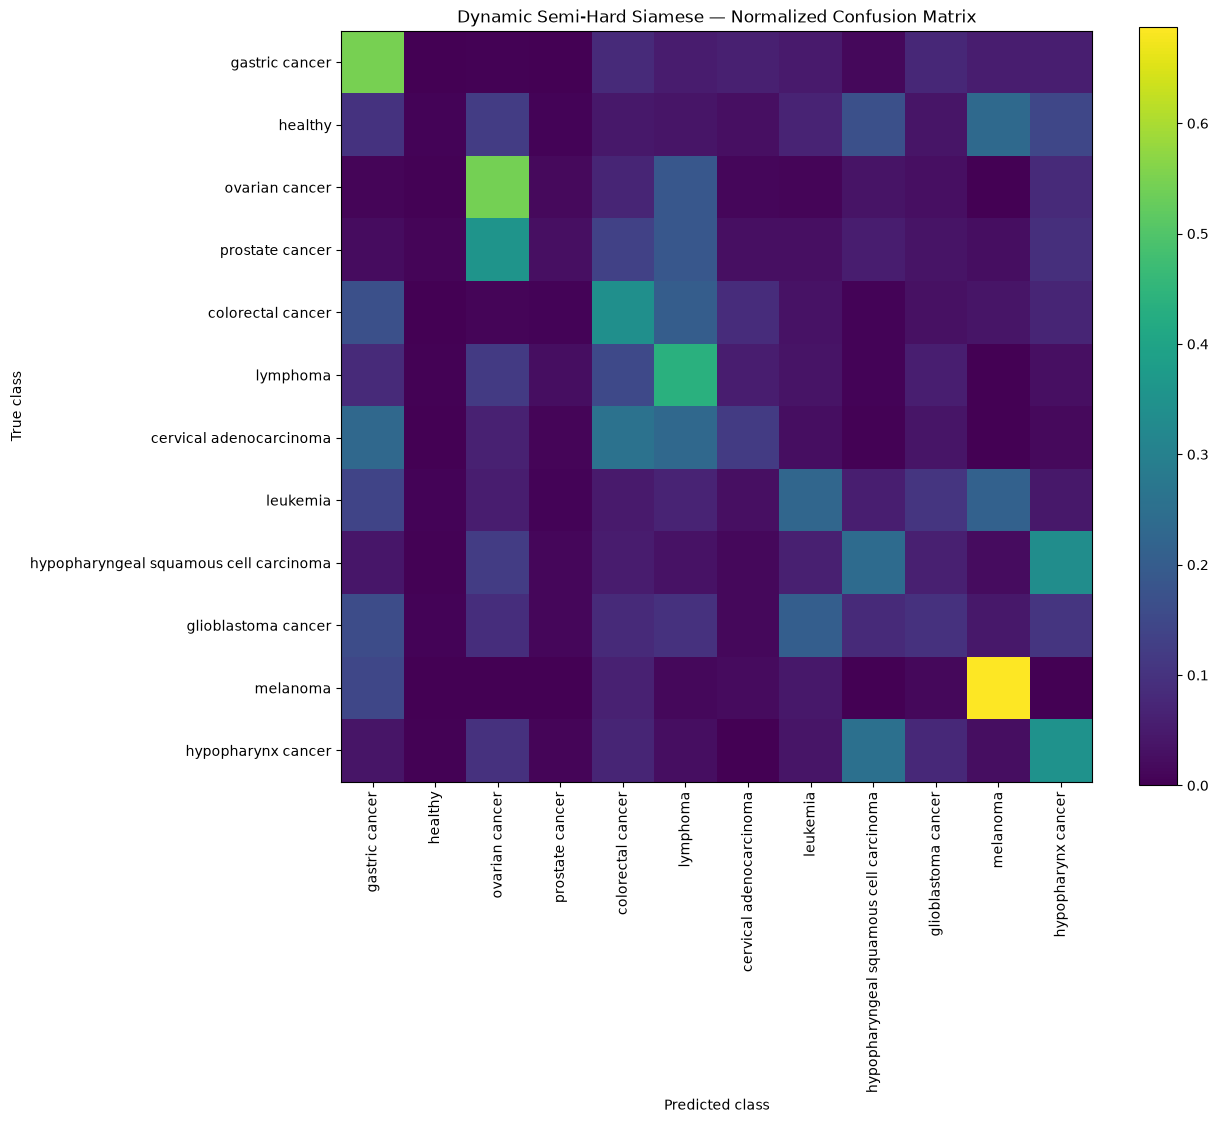

In [34]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

import matplotlib.pyplot as plt

cm = confusion_matrix(
    val_labels,
    val_predictions,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(13, 11)
)

im = ax.imshow(
    cm
)

ax.set_xticks(
    range(N_CLASSES)
)

ax.set_yticks(
    range(N_CLASSES)
)

ax.set_xticklabels(
    target_names,
    rotation=90
)

ax.set_yticklabels(
    target_names
)

ax.set_xlabel(
    "Predicted class"
)

ax.set_ylabel(
    "True class"
)

ax.set_title(
    "Dynamic Semi-Hard Siamese — Normalized Confusion Matrix"
)

plt.colorbar(
    im,
    ax=ax
)

plt.tight_layout()

plt.show()

In [35]:
# ============================================================
# REFERENCE-BANK TOP-K CLASSIFICATION
# ============================================================

TOP_K_VALUES = [
    1,
    5,
    10,
    20,
    50
]


@torch.no_grad()
def reference_bank_classification(
    query_embeddings,
    query_labels,
    reference_embeddings,
    reference_labels,
    top_k_values,
    batch_size=256
):

    top_k_values = sorted(
        top_k_values
    )

    max_k = max(
        top_k_values
    )


    # --------------------------------------------------------
    # Reference embedding per classe
    # --------------------------------------------------------

    class_reference_tensors = {}


    for class_id in range(
        N_CLASSES
    ):

        refs = reference_embeddings[
            reference_labels == class_id
        ]


        class_reference_tensors[
            class_id
        ] = torch.from_numpy(
            refs
        ).float().to(
            DEVICE
        )


    predictions_by_k = {

        k: []

        for k in top_k_values
    }


    class_scores_by_k = {

        k: []

        for k in top_k_values
    }


    # --------------------------------------------------------
    # Query batches
    # --------------------------------------------------------

    for start in range(
        0,
        len(query_embeddings),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(query_embeddings)
        )


        q = torch.from_numpy(

            query_embeddings[
                start:end
            ]

        ).float().to(
            DEVICE
        )


        # [batch, classes, max_k]
        nearest_distances_per_class = []


        for class_id in range(
            N_CLASSES
        ):

            refs = (
                class_reference_tensors[
                    class_id
                ]
            )


            # Embedding normalizzati:
            #
            # ||a-b||² = 2 - 2*cos(a,b)

            cosine = (
                q
                @
                refs.T
            )


            squared_distance = torch.clamp(

                2.0
                -
                2.0 * cosine,

                min=0.0
            )


            distances = torch.sqrt(
                squared_distance
                +
                1e-12
            )


            nearest = torch.topk(

                distances,

                k=max_k,

                dim=1,

                largest=False

            ).values


            nearest_distances_per_class.append(
                nearest
            )


        # [B, C, max_k]
        nearest_distances_per_class = (
            torch.stack(
                nearest_distances_per_class,
                dim=1
            )
        )


        # ----------------------------------------------------
        # Score per classe = media k reference più vicini
        # ----------------------------------------------------

        for k in top_k_values:

            class_scores = (

                nearest_distances_per_class[
                    :, :, :k
                ]
                .mean(
                    dim=2
                )
            )


            predictions = (
                class_scores
                .argmin(
                    dim=1
                )
            )


            predictions_by_k[k].append(

                predictions
                .cpu()
                .numpy()
            )


            class_scores_by_k[k].append(

                class_scores
                .cpu()
                .numpy()
            )


    # --------------------------------------------------------
    # Metrics
    # --------------------------------------------------------

    results = []


    for k in top_k_values:

        predictions = np.concatenate(
            predictions_by_k[k]
        )


        scores = np.concatenate(
            class_scores_by_k[k]
        )


        acc = accuracy_score(
            query_labels,
            predictions
        )


        macro_f1 = f1_score(
            query_labels,
            predictions,
            average="macro",
            zero_division=0
        )


        bal_acc = balanced_accuracy_score(
            query_labels,
            predictions
        )


        results.append(
            {
                "k":
                    k,

                "accuracy":
                    acc,

                "macro_f1":
                    macro_f1,

                "balanced_accuracy":
                    bal_acc
            }
        )


    return (
        pd.DataFrame(results),
        predictions_by_k,
        class_scores_by_k
    )

In [36]:
# ============================================================
# RUN TOP-K REFERENCE-BANK EVALUATION
# ============================================================

reference_bank_results, _, _ = (
    reference_bank_classification(

        query_embeddings=
            val_embeddings,

        query_labels=
            val_labels,

        reference_embeddings=
            reference_embeddings,

        reference_labels=
            reference_labels,

        top_k_values=
            TOP_K_VALUES,

        batch_size=256
    )
)


print("=" * 80)
print("DYNAMIC SEMI-HARD — REFERENCE-BANK CLASSIFICATION")
print("=" * 80)

display(
    reference_bank_results
)


best_row = (

    reference_bank_results
    .sort_values(
        "macro_f1",
        ascending=False
    )
    .iloc[0]
)


print()

print(
    "Best k:",
    int(
        best_row["k"]
    )
)

print(
    "Best Accuracy:",
    f"{best_row['accuracy']:.6f}"
)

print(
    "Best Macro-F1:",
    f"{best_row['macro_f1']:.6f}"
)

print(
    "Best Balanced Accuracy:",
    f"{best_row['balanced_accuracy']:.6f}"
)

DYNAMIC SEMI-HARD — REFERENCE-BANK CLASSIFICATION


,k,accuracy,macro_f1,balanced_accuracy
0,1,0.215728,0.210703,0.220053
1,5,0.285041,0.274246,0.292771
2,10,0.299395,0.283649,0.305875
3,20,0.308110,0.286888,0.313852
4,50,0.309546,0.282420,0.315769



Best k: 20
Best Accuracy: 0.308110
Best Macro-F1: 0.286888
Best Balanced Accuracy: 0.313852


In [37]:
# ============================================================
# FINAL K=6 SUMMARY
# ============================================================

k6_summary = {
    "fcgr_k": 6,
    "fcgr_shape": "64x64",
    "encoder": "CNN V3",
    "training": "dynamic semi-hard",
    "distance": "euclidean",
    "margin": 1.25,
    "embedding_dim": 128,

    "pairwise_val_auc": 0.664895,
    "pairwise_binary_accuracy": 0.6212,

    "prototype_accuracy": 0.288834,
    "prototype_macro_f1": 0.247915,
    "prototype_balanced_accuracy": 0.301971,

    "best_reference_k": 20,
    "reference_accuracy": 0.308110,
    "reference_macro_f1": 0.286888,
    "reference_balanced_accuracy": 0.313852
}

summary_df = pd.DataFrame(
    [k6_summary]
)

display(summary_df)

summary_path = (
    ARTIFACTS_DIR
    / "k6_final_summary.tsv"
)

summary_df.to_csv(
    summary_path,
    sep="\t",
    index=False
)

print(
    "Saved:",
    summary_path
)

,fcgr_k,fcgr_shape,encoder,training,distance,margin,embedding_dim,pairwise_val_auc,pairwise_binary_accuracy,prototype_accuracy,prototype_macro_f1,prototype_balanced_accuracy,best_reference_k,reference_accuracy,reference_macro_f1,reference_balanced_accuracy
0,6,64x64,CNN V3,dynamic semi-hard,euclidean,1.25,128,0.664895,0.6212,0.288834,0.247915,0.301971,20,0.30811,0.286888,0.313852


Saved: D:\Daria\Desktop\eccdna_fcgr_siamese\artifacts\siamese_dynamic_semihard_tumor_healthy\k6_final_summary.tsv
